<a href="https://colab.research.google.com/github/Knchna/ICT_AI-ML/blob/main/Case_Study_3_Jul_13_House_Prices_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Reading Dataset

In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
filepath = '/content/drive/MyDrive/ICT_AIML Class/Datasets/House_Pricing.csv'
df_house_prices = pd.read_csv(filepath)
df_house_prices.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


# Dataset Overview

In [74]:
df_house_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [75]:
df_house_prices.shape

(21613, 21)

In [76]:
''' Changed the code for value_counts() '''

for i in df_house_prices.columns:
  if df_house_prices[i].nunique() < 10000 :
    print(f"Value counts in column '{i}' is: {df_house_prices[i].value_counts()} \n")
    print(f"No of unique values in column '{i}' is: {df_house_prices[i].nunique()} \n")
    print("*************************************************")

Value counts in column 'Date House was Sold' is: Date House was Sold
15 April 2016        2231
14 July 2017         2211
14 June 2017         2180
14 August 2017       1940
14 October 2017      1878
15 March 2016        1875
14 September 2017    1774
14 May 2017          1768
14 December 2017     1471
14 November 2017     1411
15 February 2016     1250
15 January 2016       978
15 May 2016           646
Name: count, dtype: int64 

No of unique values in column 'Date House was Sold' is: 13 

*************************************************
Value counts in column 'Sale Price' is: Sale Price
350000.0    172
450000.0    171
550000.0    159
500000.0    152
425000.0    150
           ... 
357186.0      1
747450.0      1
589999.0      1
402723.0      1
999999.0      1
Name: count, Length: 3625, dtype: int64 

No of unique values in column 'Sale Price' is: 3625 

*************************************************
Value counts in column 'No of Bedrooms' is: No of Bedrooms
3     9824
4     6882


In [77]:
df_house_prices.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [78]:
df_house_prices.columns.tolist()

['ID',
 'Date House was Sold',
 'Sale Price',
 'No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Waterfront View',
 'No of Times Visited',
 'Condition of the House',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Renovated Year',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']

In [79]:
'''Added code to remove ID column as it's redundant'''

df_house_prices = df_house_prices.drop(columns = 'ID', axis = 1)

# After removing ID column
df_house_prices.shape

(21613, 20)

In [80]:
'''Added code to assign target_col'''

target_col = 'Sale Price'

In [81]:
''' Dividing into numerical and categorical cols by datatype '''

num_cols = df_house_prices.select_dtypes(include = ['int', 'float']).drop(columns = [target_col]).columns.tolist()
num_cols

['No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Renovated Year',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']

In [82]:
cat_cols = df_house_prices.select_dtypes(include = ['object']).columns.tolist()
cat_cols

['Date House was Sold',
 'Waterfront View',
 'No of Times Visited',
 'Condition of the House']

In [83]:
''' Checking 'No of Bathrooms' column values '''

df_house_prices['No of Bathrooms'].unique()

array([1.  , 2.25, 3.  , 2.  , 4.5 , 1.5 , 2.5 , 1.75, 2.75, 3.25, 4.  ,
       3.5 , 0.75, 4.75, 5.  ,  nan, 4.25, 3.75, 0.  , 1.25, 5.25, 6.  ,
       0.5 , 5.5 , 6.75, 5.75, 8.  , 7.5 , 7.75, 6.25, 6.5 ])

In [84]:
''' Conceptual division '''

# numerical columns:

continuous_cols = [
    "Flat Area (in Sqft)",
    "Lot Area (in Sqft)",
    "Area of the House from Basement (in Sqft)",
    "Basement Area (in Sqft)",
    "Latitude",
    "Longitude",
    "Living Area after Renovation (in Sqft)",
    "Lot Area after Renovation (in Sqft)"
]

discrete_cols = [
    "No of Bedrooms",
    "No of Floors",
    "Age of House (in Years)",
    "No of Bathrooms",           # Note: This column contains quantized float values
]

In [85]:
# datetime col
date_col = ["Date House was Sold"]        # Need to extract year

In [86]:
# categorical columns:
ordinal_cols = ["Overall Grade", "Condition of the House", "No of Times Visited"]

nominal_cols = [
    "Waterfront View",      # Binary Column - One-Hot Encoding OR Label Encoding
    "Zipcode"               # One-Hot Encoding
]

special_col = ["Renovated Year"]


# Data Preprocessing

In [87]:
# 1. Missing
# 2. Outlier
# 3. Duplicate
# 4. Scaling
# 5. Encoding

# Clean data

In [88]:
# 1. Missing target values
# 2. Duplicates
# 3. Datatypes and invalid values
# 4. Missing feature values
# 5. Outlier handling

## Data Cleaning

### Missing Value Identification

In [89]:
df_house_prices.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489
Condition of the House,0


### Dropping Redundant Columns

In [90]:
# Comapring missing value count in 'No of Times Visited'

missing_count = df_house_prices['No of Times Visited'].isna().sum()
total = df_house_prices.shape[0]
percentage_missing_values = (missing_count/total)*100
print(f"Percentage of missing values in 'No of Times Visited' is: {percentage_missing_values}%")

Percentage of missing values in 'No of Times Visited' is: 90.17258131680008%


In [91]:
# 'No of Times Visited' has too many missing values (>20% ??). So we drop it

df_house_prices = df_house_prices.drop(columns=['No of Times Visited'], axis=1)

In [92]:
# After dropping the redundant column
df_house_prices.shape

(21613, 19)

### Dropping Rows where the Target Col has Missing Values

In [93]:
# The target column 'Sale Price' has 4 missing values
# These shouldn't be replaced, instead remove those 4 rows

# Filtering those rows where the the target col has Null values into a df
df_house_prices[df_house_prices['Sale Price'].isna()]

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
90,14 May 2017,NaN,4,2.5,1980.0,7403.0,2.0,No,Fair,7,1980.0,0,30,0,98023.0,47.2897,-122.372,1980.0,7510
168,14 June 2017,NaN,3,2.5,2680.0,9750.0,1.0,No,Good,8,1610.0,1070,39,0,98034.0,47.7028,-122.231,2480.0,8750
21456,15 February 2016,NaN,2,1.5,1020.0,1049.0,3.0,No,Fair,8,1020.0,0,10,0,98103.0,47.6800,-122.348,1350.0,1395
21522,15 March 2016,NaN,6,3.0,2390.0,4000.0,2.0,No,Fair,7,2390.0,0,4,0,98118.0,47.5173,-122.286,1680.0,5000


In [94]:
# Before dropping the rows
df_house_prices.shape

(21613, 19)

In [95]:
# Using subset= to specify the column to dropna()

df_house_prices = df_house_prices.dropna(subset=['Sale Price'])

In [96]:
# After dropping the 4 rows
df_house_prices.shape

(21609, 19)

### Duplicates Handling

In [97]:
# Viewing the duplicate rows with original occurences too

df_house_prices[df_house_prices.duplicated(keep=False)]

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
547,15 March 2016,259950.0,2,2.00,1070.0,649.0,2.0,No,Fair,9,720.0,350,10,0,98106.0,47.5213,-122.357,1070.0,928
4352,15 March 2016,259950.0,2,2.00,1070.0,649.0,2.0,No,Fair,9,720.0,350,10,0,98106.0,47.5213,-122.357,1070.0,928
19636,15 March 2016,529500.0,3,2.25,1410.0,905.0,3.0,No,Fair,9,1410.0,0,4,0,98116.0,47.5818,-122.402,1510.0,1352
20524,15 March 2016,529500.0,3,2.25,1410.0,905.0,3.0,No,Fair,9,1410.0,0,4,0,98116.0,47.5818,-122.402,1510.0,1352


In [98]:
df_house_prices.duplicated().sum()

np.int64(2)

In [99]:
df_house_prices = df_house_prices.drop_duplicates()

In [100]:
# After dropping duplicate rows
df_house_prices.duplicated().sum()

np.int64(0)

### Checking Rows where Cols have less Missing Values

In [101]:
all_missing = df_house_prices.isna().sum()
missing_only = all_missing[all_missing > 0]         # Filtering only those columns which have isna().sum() > 0 as a series

df_house_prices.loc[:, df_house_prices.isna().sum() > 0].info()     # df.loc() is label based indexing
                # here ':' selects all rows, the parameter after that is the condition to select the required column
print(missing_only)

<class 'pandas.core.frame.DataFrame'>
Index: 21607 entries, 0 to 21612
Data columns (total 8 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   No of Bathrooms                            21603 non-null  float64
 1   Flat Area (in Sqft)                        21598 non-null  float64
 2   Lot Area (in Sqft)                         21598 non-null  float64
 3   Area of the House from Basement (in Sqft)  21604 non-null  float64
 4   Zipcode                                    21606 non-null  float64
 5   Latitude                                   21606 non-null  float64
 6   Longitude                                  21606 non-null  float64
 7   Living Area after Renovation (in Sqft)     21606 non-null  float64
dtypes: float64(8)
memory usage: 1.5 MB
No of Bathrooms                              4
Flat Area (in Sqft)                          9
Lot Area (in Sqft)                         

In [102]:
# Based on the missing value counts:
# 1) ['No of Bathrooms']         -  Discrete numerical col containing float - can use median
# 2) ['Flat Area (in Sqft)']     -  Continuous Float, use mean/median
# 3) ['Lot Area (in Sqft)']      -  Continuous Float, use mean/median
# 4) ['Area of the House from Basement (in Sqft)']    -  Continuous Float, use mean/median
# 5) ['Zipcode']                  - Categorical - only 1 NaN, but still Use mode
# 6) ['Latitude']                 - only 1 NaN, but use median
# 7) ['Longitude']                - only 1 NaN, but use median
# 8) ['Living Area after Renovation (in Sqft)']       -  1 NaN, but still mean/median

### Missing Value Imputation

<Axes: xlabel='Flat Area (in Sqft)', ylabel='Count'>

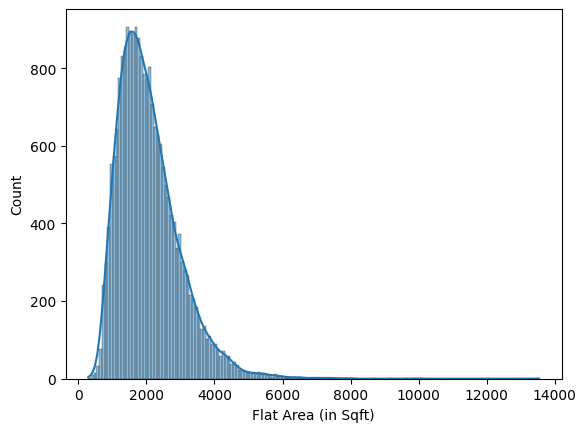

In [103]:
# 'Flat Area (in Sqft)':
# Graph is right skewed with long tail
sns.histplot(df_house_prices['Flat Area (in Sqft)'], kde=True)

<Axes: xlabel='Lot Area (in Sqft)', ylabel='Count'>

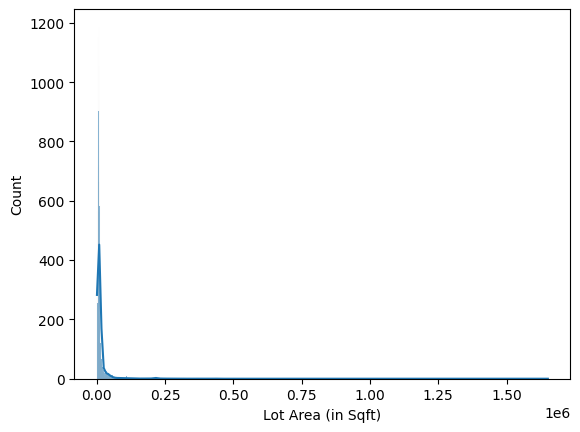

In [104]:
# 'Lot Area (in Sqft)':
# Graph is extremely-right skewed with long tail

sns.histplot(df_house_prices['Lot Area (in Sqft)'], kde=True)

<Axes: xlabel='Area of the House from Basement (in Sqft)', ylabel='Count'>

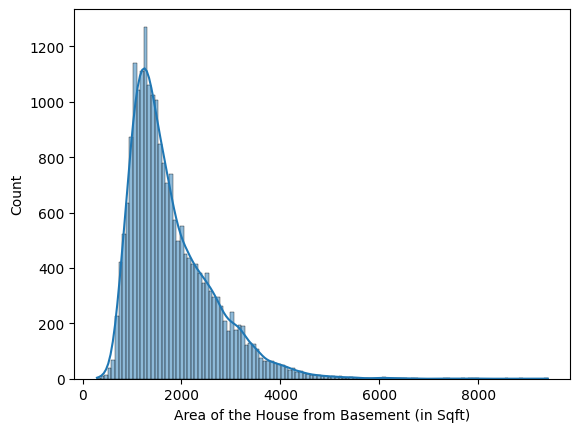

In [105]:
# 'Area of the House from Basement (in Sqft)':
# Graph is right skewed

sns.histplot(df_house_prices['Area of the House from Basement (in Sqft)'], kde=True)

<Axes: xlabel='Living Area after Renovation (in Sqft)', ylabel='Count'>

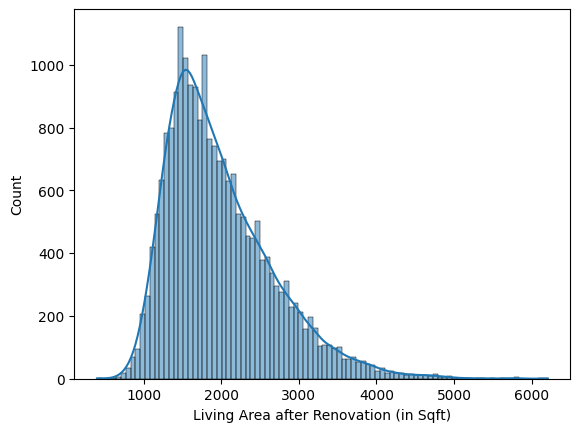

In [106]:
# 'Living Area after Renovation (in Sqft)':
# Graph is right skewed with long tail
sns.histplot(df_house_prices['Living Area after Renovation (in Sqft)'], kde=True)

In [108]:
# These are having right-skewed plots, so we use median for imputation of missing values

cols = [
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Living Area after Renovation (in Sqft)',
    'No of Bathrooms',
    'Latitude',
    'Longitude'
]

for i in cols:
  df_house_prices[i] = df_house_prices[i].fillna(df_house_prices[i].median())

In [109]:
df_house_prices['Zipcode'] = df_house_prices['Zipcode'].fillna(df_house_prices['Zipcode'].mode()[0])

In [110]:
# After imputation
df_house_prices.isnull().sum()

,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0


### Outlier Handling

In [ ]:
# Filtering numerical columns by datatype
# Dropping ID as it is a categorical col with unique values


In [ ]:
# Filtering categorical columns by datatype


In [ ]:
# Visualizing outliers by subplotting all boxplots of the columns in num_col

plt.figure(figsize=(16, 12))

i = 1
for column in num_cols:
  plt.subplot(4, 4, i)              # i only denotes the position of the boxplot while subplotting
  sns.boxplot(df_house_prices[column])
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

In [ ]:
num_cols.describe()

In [ ]:

num_cols.columns.tolist()

In [ ]:
# 'Sale Price': Is the target column. So no handling outliers

In [ ]:
# 'No of Floors', 'Overall Grade', 'Zipcode', 'Latitude', 'Longitude', 'Renovated Year' => Categorical Cols containing discrete numeric data
# No need to handle outliers in these 6 cols as they are categorical cols with discrete numeric values

In [ ]:
# 'Age of House (in Years)': Categorical Col with discrete int values
# Has no outliers

In [ ]:
# Remaining 8 cols
num_cols_outliers = num_cols.drop(columns=['Sale Price','No of Floors', 'Overall Grade', 'Zipcode', 'Latitude', 'Longitude',
                                           'Renovated Year', 'Age of House (in Years)'], axis=1)
len(num_cols_outliers.columns.tolist())

In [ ]:
num_cols.columns.tolist()

In [ ]:
# Drawing histograms of the 8 columns

plt.figure(figsize=(16, 12))

i = 1
for column in num_cols_outliers:
  plt.subplot(2, 4, i)              # i only denotes the position of the histplot while subplotting
  sns.histplot(num_cols_outliers[column], kde=True, bins=30)
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

In [ ]:
# Boxplots of the 8 columns

plt.figure(figsize=(16, 12))

i = 1
for column in num_cols_outliers:
  plt.subplot(2, 4, i)              # i only denotes the position of the boxplot while subplotting
  sns.boxplot(num_cols_outliers[column])
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

In [ ]:
# 'No of Bedrooms': Categorical Col with discrete numeric int values
# => skewed graph with long right tail
df_house_prices['No of Bedrooms'].value_counts()

In [ ]:
df_house_prices['No of Bedrooms'] = df_house_prices['No of Bedrooms'].clip(upper=11)

# But the value=33 is extremely distant from other values
# So we clip only 33 to the value 11

# After clipping
df_house_prices['No of Bedrooms'].unique()

In [ ]:
# 'No of Bathrooms': Categorical Col with large no of unique float values
# Range = 8, min = 0, max = 8, mean = 2

# there isn't much outlier values in this case

df_house_prices['No of Bathrooms'].value_counts()

In [ ]:
# Creating groups for all unique values in 'No of Bathrooms',
  # then finding mean of 'Sale Price' for each group,
  # then sorting the groups by ascending order of 'No of Bathrooms'

df_house_prices.groupby('No of Bathrooms')['Sale Price'].mean().sort_index()

In [ ]:
# Most values lie in the range 0-5, remaining values >5 are less in comparison
# But there is a clear upward trend in Sales Price as No of Bathroom increases
# So values >5 are genuine important data
# So we don't perform outlier handling here

In [ ]:
# 'Flat Area (in Sqft)': Continuous Numeric Col
# Histogram is right-skewed with somewhat long right-tail
# There are 2 values (near 12k and 14k) that are more distant from other outlier values from the boxplot
# But we still have to infer to decide on outlier handling

# To find largest n vales in Flat Area
large_flat_area = df_house_prices['Flat Area (in Sqft)'].nlargest(5)
large_flat_area

In [ ]:
# Higher flat area doesn't necessarily mean higher Sale Price

df_house_prices[['Flat Area (in Sqft)', 'Sale Price']].nlargest(20, 'Flat Area (in Sqft)')

In [ ]:
df_house_prices.nlargest(10, 'Flat Area (in Sqft)')

In [ ]:
# It's necessary to let the model know that higher flat !=> higher sale price.
# So we don't outlier handle 'Flat Area (in Sqft)'

# If linear regression is being done, then we can consider log transformation
  # later while Feature Engineering to handle the skewness
# But the Col can be left as is if were doing RandomForest or DecisionTree etc.

In [ ]:
# 'Lot Area (in Sqft)': Continuous Numeric Col
# Histogram is extremely right-skewed with very long tail
# We use log-transformation to scale the values without capping/affecting the outliers
# And this columns doesn't contain any 0 values so

df_house_prices['Lot Area (in Sqft)'] = np.log(df_house_prices['Lot Area (in Sqft)'])

In [ ]:
# After Log transformation
sns.histplot(df_house_prices['Lot Area (in Sqft)'])

In [ ]:
# 'Area of the House from Basement (in Sqft)': Continuous Numeric Col
# Histogram is right-skewed with somewhat long right-tail
# But tail is having genuine data just like in 'Flat Are (in Sqft)'
# So we skip outlier handling here also

# If linear regression is being done, then we can consider log transformation
  # later while Feature Engineering to handle the skewness
# But the Col can be left as is if were doing RandomForest or DecisionTree etc.

In [ ]:
# 'Basement Area (in Sqft)': Continous Numeric Col
# But majority rows has Basement Area = 0, but some cols have extreme high values

# But large basements in large homes are genuine data points
# To find largest n vales in Basement Area
large_basements = df_house_prices['Basement Area (in Sqft)'].nlargest(20)
large_basements

In [ ]:
df_house_prices[['Basement Area (in Sqft)','Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'Sale Price']].nlargest(20, 'Basement Area (in Sqft)')

In [ ]:
# This shows that 'Basement Area' values are ≈ 50% of the Flat Area values
# So we apply the same deduction for Flat Area here as the extreme values are genuine
# Skip outlier handling for 'Basement Area (in Sqft)'

# But since majority houses have 0 Basements,
  # it may be required to create a new binary feature column under Feature Engineering
  # called 'Has_Basement' to specify if basement is present or not

In [ ]:
# 'Living Area after Renovation (in Sqft)': Continous Numerical Col
# => Right-Skewed with gradual tail
# The extreme values are genuine and not handled

# If we're using Regression, this column can be long transformed under Feature Engineering

In [ ]:
# 'Lot Area after Renovation (in Sqft)': Continuous Numerical Col
# Histogram is extremely right-skewed with very long tail
# We use log-transformation to scale the values without capping/affecting the outliers
# And this columns doesn't contain any 0 values so

df_house_prices['Lot Area after Renovation (in Sqft)'] = np.log(df_house_prices['Lot Area after Renovation (in Sqft)'])

In [ ]:
# df_house_prices[['Lot Area (in Sqft)', 'Lot Area after Renovation (in Sqft)']]

In [ ]:
# df_house_prices[['Flat Area (in Sqft)', 'Living Area after Renovation (in Sqft)']]

## Data Transformation

In [ ]:
num_cols = df_house_prices[num_cols_outliers.columns]
print(num_cols.columns.tolist())
print(cat_cols.columns.tolist())

In [ ]:
# Modifying num_cols and cat_cols based on continuous or discrete numerical value cols

discrete_num_cols = ['ID', 'No of Bedrooms', 'No of Bathrooms', 'No of Floors', 'Overall Grade', 'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude', 'Longitude']
num_cols = num_cols.drop(columns=['No of Bedrooms', 'No of Bathrooms'], axis=1)
cat_cols = pd.concat([cat_cols, df_house_prices[discrete_num_cols]])

In [ ]:
print(num_cols.columns.tolist())
print(cat_cols.columns.tolist())

In [ ]:
# Cross checking

print(num_cols.shape[1])
print(cat_cols.shape[1])
df_house_prices.shape

### Scaling

In [ ]:
# Manually Identify target col, and put remaining non-numeric cols as feature cols
target_col = ['Sale Price']
# Target col is not scaled because it's the target

In [ ]:
# Create lists of continuous numerical columns with sysmmetric and skewed dists. for determining scaling method
minmax_cols = num_cols.columns.tolist()
minmax_cols

In [ ]:
plt.figure(figsize=(16,8))

i=1
for column in num_cols[['Lot Area (in Sqft)', 'Lot Area after Renovation (in Sqft)']]:
  plt.subplot(1, 2, i)
  sns.histplot(num_cols[column], kde=True)
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

In [ ]:
# Before minmax scaling
df_house_prices[minmax_cols].head()

In [ ]:
# Creating an object of the MinMax Class to use for scaling
minmax_scaler = MinMaxScaler()

df_house_prices[minmax_cols] = minmax_scaler.fit_transform(df_house_prices[minmax_cols])

In [ ]:
# After minmax scaling
df_house_prices[minmax_cols].head()

### Encoding

In [ ]:
# For identifying feature cols;
  # 'ID' - only used to specify the house/row. No use in prediction. Can be dropped from feature columns


feature_cols = df_house_prices[cat_cols.columns].drop(columns=['ID'], axis=1).columns.tolist()
feature_cols



In [ ]:
df_house_prices.drop(columns=['ID'], axis=1, inplace=True)                # Permanently removing redundant column

In [ ]:
# Identifying binary feature columns
df_house_prices['Waterfront View'].unique()

#### Label encoding

In [ ]:
# Object
label_encoder = LabelEncoder()    # Only for target col and binary feature cols

df_house_prices['Waterfront View'] = label_encoder.fit_transform(df_house_prices['Waterfront View'])

In [ ]:
# After label encoding
df_house_prices['Waterfront View'].head()

#### Ordinal Encoding

In [ ]:
print(df_house_prices['Condition of the House'].unique())
print(df_house_prices['Overall Grade'].unique())

In [ ]:
# creating custom order for these 2 columns
condition_order = ['Bad', 'Okay', 'Fair', 'Good', 'Excellent']
grade_order = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
# creating object
ordinal_encoder = OrdinalEncoder(categories=[condition_order, grade_order])

# Apply to both columns simultaneously
df_house_prices[['Condition of the House', 'Overall Grade']] = ordinal_encoder.fit_transform(
    df_house_prices[['Condition of the House', 'Overall Grade']]
)

#### One-Hot Encoding

In [ ]:
# No need because
  # remaining feature columns like Zipcode, Longitude, Latitude etc contain unique discrete tnumerical data already

# Train Test Split

In [ ]:
print(df_house_prices.isnull().sum())
df_house_prices.shape

In [ ]:
print(df_house_prices.dtypes)

In [ ]:
# Separate features and target
X = df_house_prices.drop(target_col, axis=1)
y = df_house_prices[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify shapes
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")